# An example of writting code with adjustable settings


In [251]:
# Creating a dataset using randomly generated data

# df1 Random dataset

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

Month = ["January", "February", "March"]
mm= len(Month)

inf = ["Operational_Spend", "Marketing_Spend", "Administrative_Spend"]
mi = len(inf)

prt = np.random.randint(5500, 6500, size = (mm, mi)) # here are parametres what could be adjusted

df1 = pd.DataFrame(prt, index= Month, columns= inf)

df1.loc["Total"]=df1.sum()
df1["Total"]=df1.sum(axis=1)

df1

,Operational_Spend,Marketing_Spend,Administrative_Spend,Total
January,5606,5514,5565,16685
February,6369,5693,5777,17839
March,6390,6468,5908,18766
Total,18365,17675,17250,53290


In [252]:
# Creating a dataset with other data

# df2 dataset with other data

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


Month = ["April", "May", "June"]

Marketing_Spend = (6787, 7126, 7400)
Operational_Spend = (6786, 6833, 7106)
Administrative_Spend = (7098, 7596, 8126)



array = np.array([Month, Marketing_Spend, Operational_Spend, Administrative_Spend])

data2 = {
    "Operational_Spend":Operational_Spend,
    "Marketing_Spend":Marketing_Spend,
    "Administrative_Spend":Administrative_Spend
        }

df2 = pd.DataFrame(data2, index= Month)

df2.loc["Total"] = df2.sum()
df2["Total"] = df2.sum(axis=1)

df2




,Operational_Spend,Marketing_Spend,Administrative_Spend,Total
April,6786,6787,7098,20671
May,6833,7126,7596,21555
June,7106,7400,8126,22632
Total,20725,21313,22820,64858


In [253]:
# Combining two datasets into one database

# df merged database

import pandas as pd

df = pd.concat([
    df1.drop("Total"),
    df2.drop("Total")
    ])

df.loc["Total"] = df.sum()


df

,Operational_Spend,Marketing_Spend,Administrative_Spend,Total
January,5606,5514,5565,16685
February,6369,5693,5777,17839
March,6390,6468,5908,18766
April,6786,6787,7098,20671
May,6833,7126,7596,21555
June,7106,7400,8126,22632
Total,39090,38988,40070,118148


In [254]:
# An overview of the data

df.describe()

,Operational_Spend,Marketing_Spend,Administrative_Spend,Total
count,7.000000,7.000000,7.000000,7.000000
mean,11168.571429,11139.428571,11448.571429,33756.571429
std,12321.577305,12299.788452,12658.834199,37272.207460
min,5606.000000,5514.000000,5565.000000,16685.000000
25%,6379.500000,6080.500000,5842.500000,18302.500000
50%,6786.000000,6787.000000,7098.000000,20671.000000
75%,6969.500000,7263.000000,7861.000000,22093.500000
max,39090.000000,38988.000000,40070.000000,118148.000000


In [255]:
# Correlation data based on  January's indicators


df.insert(1,"OpSpend_Dynamics", (df.iloc[:,0]/df.iloc[0,0] * 100) -100 )
df.insert(3, "MarkSpend_Dynamics", (df.iloc[:,2]/df.iloc[0,2] * 100) - 100)
df.insert(5, "AdmSpend_Dynamics", (df.iloc[:,4]/df.iloc[0,4] * 100) - 100)

df

,Operational_Spend,OpSpend_Dynamics,Marketing_Spend,MarkSpend_Dynamics,Administrative_Spend,AdmSpend_Dynamics,Total
January,5606,0.000000,5514,0.000000,5565,0.000000,16685
February,6369,13.610417,5693,3.246282,5777,3.809524,17839
March,6390,13.985016,6468,17.301415,5908,6.163522,18766
April,6786,21.048876,6787,23.086688,7098,27.547170,20671
May,6833,21.887264,7126,29.234675,7596,36.495957,21555
June,7106,26.757046,7400,34.203845,8126,46.019766,22632
Total,39090,597.288619,38988,607.072905,40070,620.035939,118148


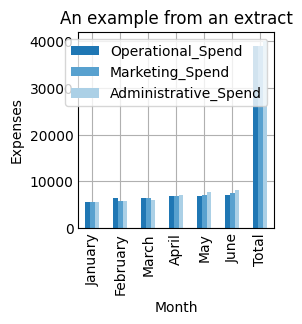

In [256]:
# An example of vizualization in Matplotlib

# Plot 1
# "Overview of Monthly and Total Trends"

import matplotlib.pyplot as plt
import numpy as np

df_plotT = df
df_plot = df.drop("Total")

df_plotT[["Operational_Spend", "Marketing_Spend", "Administrative_Spend"]].plot(kind= "bar")

plt.title("An example from an extract")
plt.xlabel("Month")
plt.ylabel("Expenses")

plt.grid(True)

plt.show()

<Axes: >

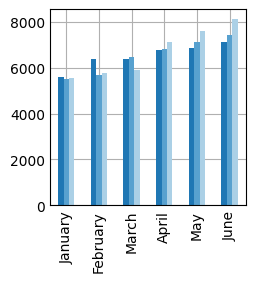

In [257]:
# Plot 2

# "An overview of the monthly dynamics of indicators"

df_plot[["Operational_Spend", "Marketing_Spend", "Administrative_Spend"]].plot(kind= "bar", legend= False)


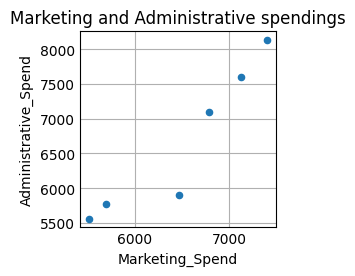

In [258]:
# Plot 3

df_plot.plot.scatter(
    x ="Marketing_Spend",
    y="Administrative_Spend")

plt.title("Marketing and Administrative spendings")
plt.show()

<Axes: >

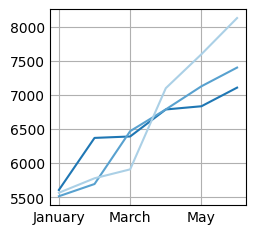

In [259]:
# Plot 4


from matplotlib import colors

df_plot[["Operational_Spend", "Marketing_Spend", "Administrative_Spend"]].plot(kind= "line", legend = False )

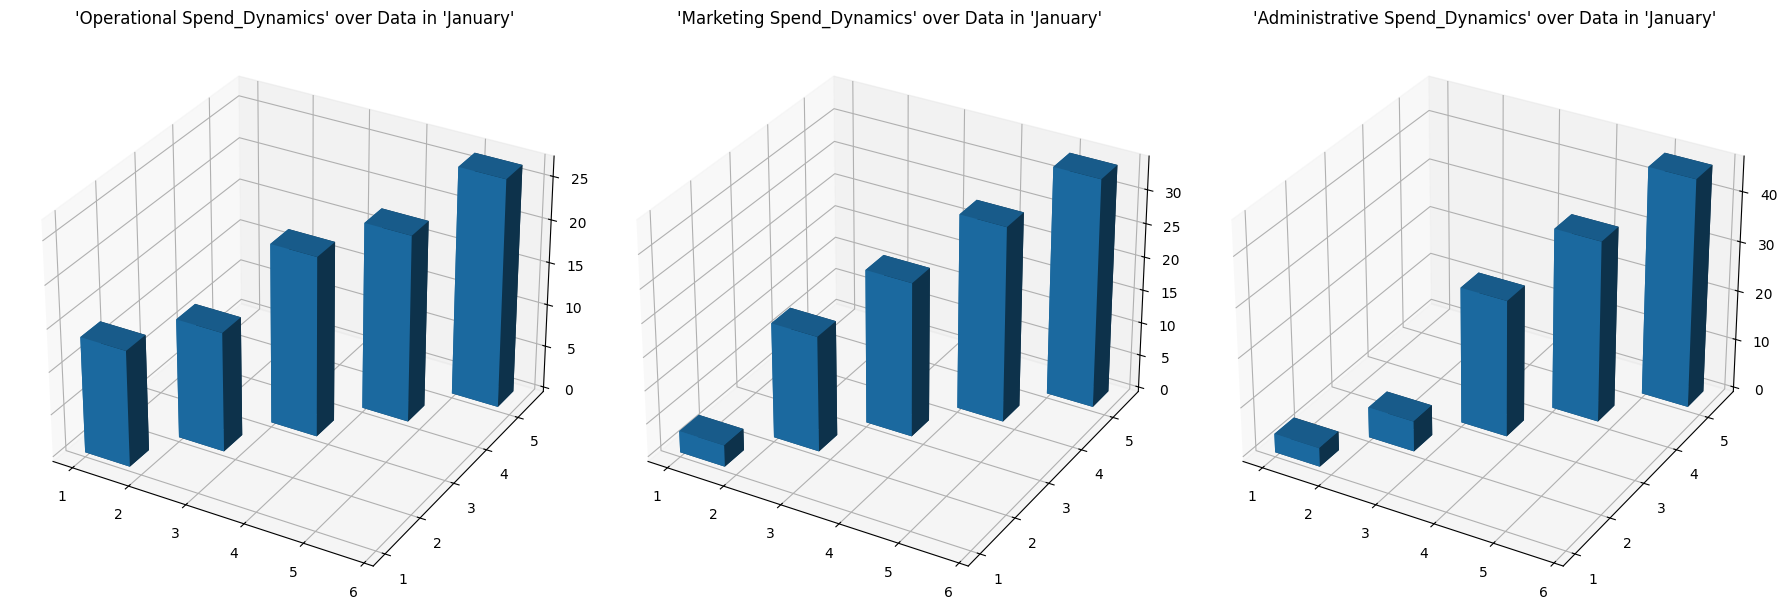

In [260]:
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('_mpl-gallery')

x = [1, 2, 3, 4, 5]
y = [1, 2, 3, 4, 5]
z = [0, 0, 0, 0, 0]
k = [0, 0, 0, 0, 0]
l = [0, 0, 0, 0, 0]


dx = np.ones_like(x) * 0.8
dy = np.ones_like(x) * 0.5

dz = df.iloc[1:6, 1]
dk = df.iloc[1:6, 3]
dl = df.iloc[1:6, 5]


fig, (ax1, ax2, ax3) = plt.subplots(
    1, 3,
    figsize=(18, 6),
    subplot_kw={"projection": "3d"}
    )


# plot 1
ax1.bar3d(x, y, z, dx, dy, dz)
ax1.set_title("'Operational Spend_Dynamics' over Data in 'January'")

# plot 2
ax2.bar3d(x, y, k, dx, dy, dk)
ax2.set_title("'Marketing Spend_Dynamics' over Data in 'January'")

# plot 3
ax3.bar3d(x, y, l, dx, dy, dl)
ax3.set_title("'Administrative Spend_Dynamics' over Data in 'January'")

plt.tight_layout()
plt.show()